In [42]:
import pandas as pd

df = pd.read_csv("scalabilityExperimentMSDv2.csv")
df = pd.read_csv("partial/scalabilityExperimentcVaR_partial.csv")

In [43]:
display(df)
plot_df = df.copy()

plot_df["method_small"] = "small_support"
plot_df["method_mcp"] = "path_MCP"
plot_df["problem_size"] = plot_df["K"] * plot_df["n"] * plot_df["n"]

summary = plot_df.groupby(["K", "n", "kappa", "tau"], as_index=False, dropna=False).agg(
    reps=("seed", "count"),
    problem_size=("problem_size", "first"),
    small_success_rate=("small_success", "mean"),
    mcp_success_rate=("mcp_success", "mean"),
    small_time_median=("small_time_s", "median"),
    mcp_time_median=("mcp_time_s", "median"),
    small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
    small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
    mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
    mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
    small_eta_median=("small_eta", "median"),
    mcp_eta_median=("mcp_eta", "median"),
)

small_summary = (
    plot_df[plot_df["small_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_small=("seed", "count"),
        problem_size=("problem_size", "first"),
        small_time_median=("small_time_s", "median"),
        small_time_q25=("small_time_s", lambda x: x.quantile(0.25)),
        small_time_q75=("small_time_s", lambda x: x.quantile(0.75)),
        small_eta_median=("small_eta", "median"),
    )
)

mcp_summary = (
    plot_df[plot_df["mcp_success"]]
    .groupby(["K", "n", "kappa", "tau"], as_index=False)
    .agg(
        reps_succ_mcp=("seed", "count"),
        problem_size=("problem_size", "first"),
        mcp_time_median=("mcp_time_s", "median"),
        mcp_time_q25=("mcp_time_s", lambda x: x.quantile(0.25)),
        mcp_time_q75=("mcp_time_s", lambda x: x.quantile(0.75)),
        mcp_eta_median=("mcp_eta", "median"),
    )
)

success_summary = mcp_summary.merge(
    small_summary, on=["K", "n", "kappa", "tau", "problem_size"], how="outer"
)
display(success_summary)
display(summary)

,K,n,seed,gamma,alpha,eps,kappa,tau,small_time_s,small_success,small_eta,mcp_time_s,mcp_success,mcp_eta
0,5,5,50623,0.5,0.05,0.01,3,5,2038.644749,False,0.011257,0.094232,True,1.073047e-11
1,5,5,50624,0.5,0.05,0.01,3,5,342.988466,True,0.009086,0.118366,True,2.220446e-16
2,5,5,50625,0.5,0.05,0.01,3,5,64.524745,True,0.009350,0.094544,True,-4.946210e-12
3,5,5,50626,0.5,0.05,0.01,3,5,2074.513477,False,0.010447,0.093493,True,-8.223866e-12
4,5,5,50627,0.5,0.05,0.01,3,5,1718.918002,False,0.013097,0.134571,True,-2.097433e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,500,10,5001130,0.5,0.05,0.01,4,23,9413.637478,False,0.025861,51.178878,False,NaN
428,500,10,5001131,0.5,0.05,0.01,4,23,9686.553640,False,0.030611,78.524609,False,NaN
429,500,10,5001132,0.5,0.05,0.01,4,23,8944.766675,False,0.027844,120.577347,False,NaN
430,500,10,5001133,0.5,0.05,0.01,4,23,7957.210629,False,0.024202,90.830098,False,NaN


,K,n,kappa,tau,reps_succ_mcp,problem_size,mcp_time_median,mcp_time_q25,mcp_time_q75,mcp_eta_median,reps_succ_small,small_time_median,small_time_q25,small_time_q75,small_eta_median
0,5,5,3,5,20,125,0.111648,0.096611,0.127417,-5.398459e-14,15.0,62.402945,24.565127,163.645634,0.005262
1,5,10,4,5,19,500,0.195856,0.177175,0.247596,3.330669e-16,17.0,146.746597,52.969787,239.713872,0.007048
2,5,20,5,5,4,2000,0.371752,0.336025,0.427286,-2.465750e-12,14.0,703.366001,172.663201,1530.806228,0.007871
3,5,50,8,5,1,12500,1.870900,1.870900,1.870900,-1.003675e-11,5.0,1429.781499,1262.560944,2182.215390,0.006107
4,10,5,3,5,20,250,0.125512,0.113492,0.140792,-2.661288e-12,20.0,197.683933,82.179097,460.918666,0.007160
5,10,10,4,5,15,1000,0.158280,0.152397,0.220439,-6.191159e-12,9.0,296.224240,84.015896,1579.447262,0.007045
6,10,20,5,5,2,4000,0.322330,0.319958,0.324703,-1.961505e-10,1.0,2015.828386,2015.828386,2015.828386,0.009615
7,30,5,3,6,20,750,0.173067,0.129836,0.221806,-1.600929e-10,14.0,244.471784,115.105892,637.514156,0.007426
8,30,10,4,6,4,3000,0.376522,0.342026,0.397753,-3.094638e-09,NaN,NaN,NaN,NaN,NaN
9,100,5,3,10,20,2500,0.673955,0.554319,1.040776,-4.125454e-10,4.0,1163.404872,964.136696,1538.419196,0.007389


,K,n,kappa,tau,reps,problem_size,small_success_rate,mcp_success_rate,small_time_median,mcp_time_median,small_time_q25,small_time_q75,mcp_time_q25,mcp_time_q75,small_eta_median,mcp_eta_median
0,5,5,3,5,20,125,0.75,1.00,132.225653,0.111648,29.786022,716.311695,0.096611,0.127417,0.007911,-5.398459e-14
1,5,10,4,5,20,500,0.85,0.95,196.817256,0.194921,57.147619,434.349928,0.177401,0.242064,0.007615,4.996004e-16
2,5,20,5,5,20,2000,0.70,0.20,1432.132448,0.575719,452.269605,3118.761165,0.408209,0.617426,0.009616,2.972154e-02
3,5,50,8,5,20,12500,0.25,0.05,4585.625431,2.405478,3816.046484,5266.524538,1.881436,2.521778,0.014739,4.257868e+00
4,10,5,3,5,20,250,1.00,1.00,197.683933,0.125512,82.179097,460.918666,0.113492,0.140792,0.007160,-2.661288e-12
5,10,10,4,5,20,1000,0.45,0.75,1862.738452,0.194196,674.856865,2437.677894,0.155142,0.286316,0.010256,-6.191159e-12
6,10,20,5,5,20,4000,0.05,0.10,2226.354677,0.593099,2050.597506,2377.220921,0.558867,0.669251,0.022115,-4.498169e-11
7,10,50,8,5,20,25000,0.00,0.00,2664.393001,2.493509,2456.877673,2806.728439,2.256610,2.611905,0.100888,NaN
8,30,5,3,6,20,750,0.70,1.00,626.066064,0.173067,163.873290,1249.267926,0.129836,0.221806,0.008556,-1.600929e-10
9,30,10,4,6,20,3000,0.00,0.20,1689.854675,0.700038,1642.682345,1774.772410,0.406642,0.749352,0.023730,-3.094638e-09


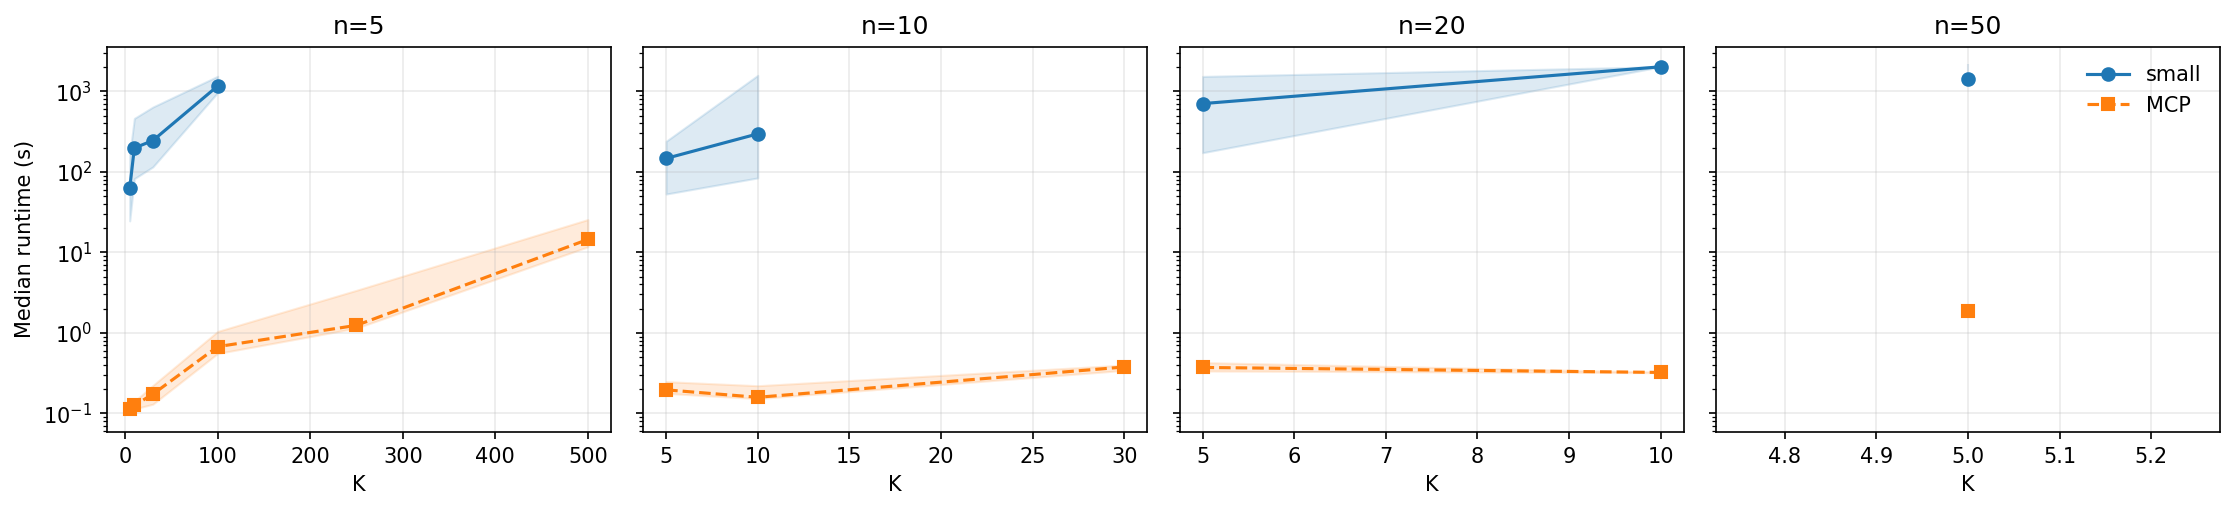

In [44]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

small_color = "tab:blue"
mcp_color = "tab:orange"
fig, axes = plt.subplots(1, len(n_grid), figsize=(15, 3.5), dpi=150, sharey=True)

for ax, n in zip(axes, n_grid):
    s = success_summary[success_summary["n"] == n].sort_values("K")

    ax.plot(s["K"], s["small_time_median"], "o-", label="small", color=small_color)
    ax.fill_between(
        s["K"],
        s["small_time_q25"],
        s["small_time_q75"],
        color=small_color,
        alpha=0.15,
        label="_nolegend_",
    )

    ax.plot(s["K"], s["mcp_time_median"], "s--", label="MCP", color=mcp_color)
    ax.fill_between(
        s["K"],
        s["mcp_time_q25"],
        s["mcp_time_q75"],
        color=mcp_color,
        alpha=0.15,
        label="_nolegend_",
    )

    ax.set_yscale("log")
    ax.set_title(f"n={n}")
    ax.set_xlabel("K")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Median runtime (s)")
axes[-1].legend(frameon=False)
plt.tight_layout()
plt.show()

# remove header
# add no successful runs and legend
# describe the setup for the experiment and the hardware

In [52]:
import numpy as np
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

cmap = plt.get_cmap("inferno")
small_color = cmap(0.25)
mcp_color = cmap(0.75)

fig, axes = plt.subplots(
    1,
    len(n_grid),
    figsize=(15, 3.5),
    dpi=150,
    sharey=True,
)

for ax, n in zip(axes, n_grid):
    s = summary[summary["n"] == n].sort_values("K")

    small_zero = s["small_success_rate"] == 0
    mcp_zero = s["mcp_success_rate"] == 0

    # Lines only, no markers
    ax.plot(
        s["K"],
        s["small_time_median"],
        "-",
        color=small_color,
        linewidth=1.8,
        label="small-support" if n == n_grid[0] else "_nolegend_",
    )
    ax.plot(
        s["K"],
        s["mcp_time_median"],
        "--",
        color=mcp_color,
        linewidth=1.8,
        label="MCP" if n == n_grid[0] else "_nolegend_",
    )

    # IQR bands
    ax.fill_between(
        s["K"],
        s["small_time_q25"],
        s["small_time_q75"],
        color=small_color,
        alpha=0.15,
    )
    ax.fill_between(
        s["K"],
        s["mcp_time_q25"],
        s["mcp_time_q75"],
        color=mcp_color,
        alpha=0.15,
    )

    # Normal markers only where success rate > 0
    ax.scatter(
        s.loc[~small_zero, "K"],
        s.loc[~small_zero, "small_time_median"],
        marker="o",
        s=28,
        color=small_color,
        zorder=4,
    )
    ax.scatter(
        s.loc[~mcp_zero, "K"],
        s.loc[~mcp_zero, "mcp_time_median"],
        marker="s",
        s=28,
        color=mcp_color,
        zorder=4,
    )

    # Cross markers only where success rate == 0
    ax.scatter(
        s.loc[small_zero, "K"],
        s.loc[small_zero, "small_time_median"],
        marker="x",
        s=70,
        linewidths=2.0,
        color=small_color,
        label="small-support: failed" if n == n_grid[0] else "_nolegend_",
        zorder=5,
    )
    ax.scatter(
        s.loc[mcp_zero, "K"],
        s.loc[mcp_zero, "mcp_time_median"],
        marker="x",
        s=70,
        linewidths=2.0,
        color=mcp_color,
        label="MCP: failed" if n == n_grid[0] else "_nolegend_",
        zorder=5,
    )

    ax.set_yscale("log")
    ax.set_title(f"n={n}", fontsize=15)
    ax.set_xlabel("K", fontsize=15)
    ax.tick_params(labelsize=15)
    ax.grid(alpha=0.25)
    if n not in [20, 50]:
        ax.set_xticks(range(100, 501, 100))
    else:
        ax.set_xticks(range(100, 301, 100))

axes[0].set_ylabel("Median runtime (s)", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=15,
)
fig.set_dpi(1200)
plt.tight_layout()
plt.show()

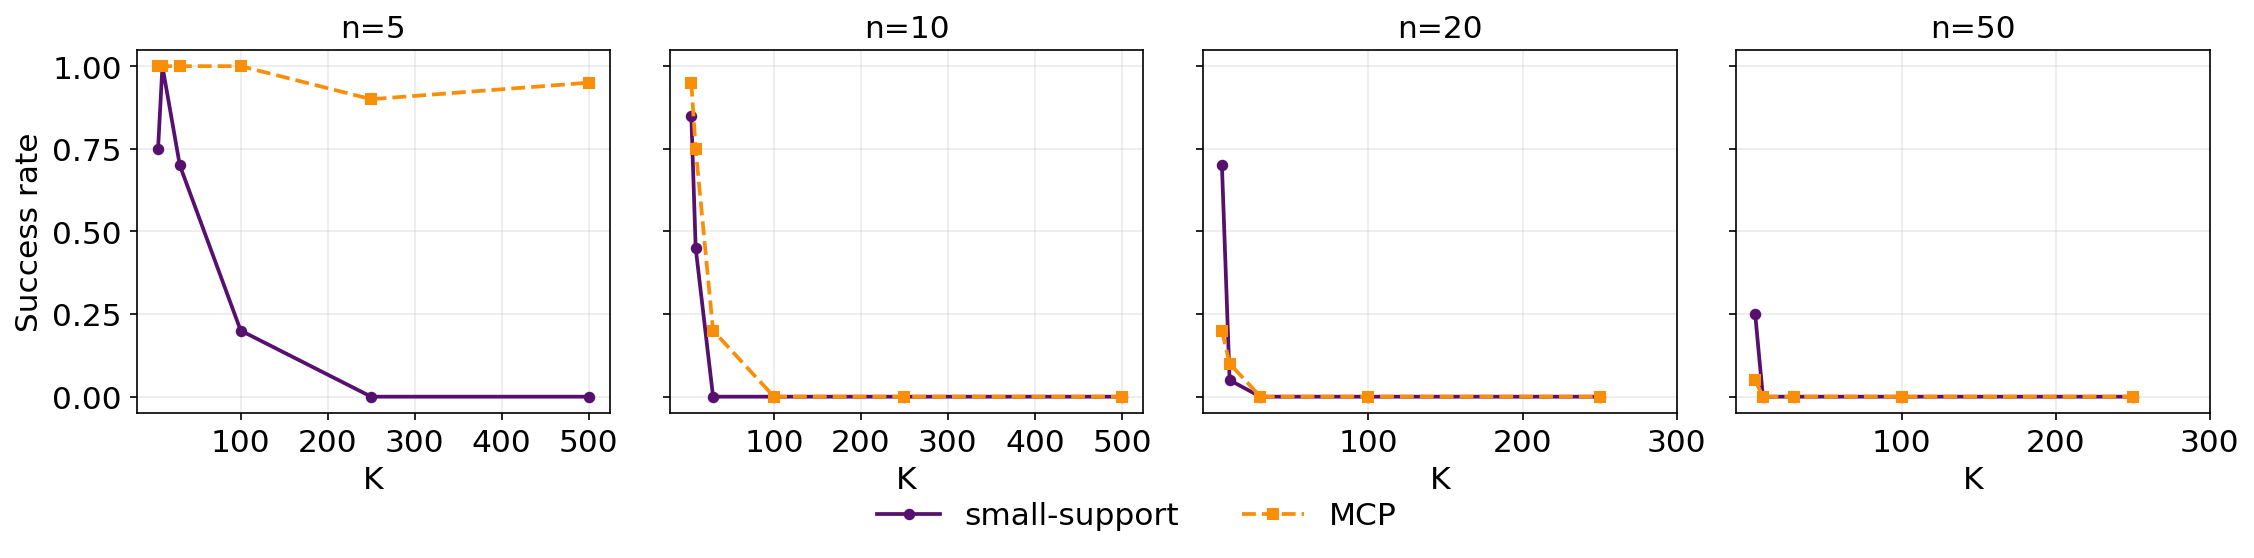

In [54]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]

cmap = plt.get_cmap("inferno")
small_color = cmap(0.25)
mcp_color = cmap(0.75)

fig, axes = plt.subplots(
    1,
    len(n_grid),
    figsize=(15, 3.5),
    dpi=150,
    sharey=True,
)

for ax, n in zip(axes, n_grid):
    s = summary[summary["n"] == n].sort_values("K")

    ax.plot(
        s["K"],
        s["small_success_rate"],
        "o-",
        label="small-support" if n == n_grid[0] else "_nolegend_",
        color=small_color,
        linewidth=1.8,
        markersize=4.5,
    )

    ax.plot(
        s["K"],
        s["mcp_success_rate"],
        "s--",
        label="MCP" if n == n_grid[0] else "_nolegend_",
        color=mcp_color,
        linewidth=1.8,
        markersize=4.5,
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"n={n}", fontsize=15)
    ax.set_xlabel("K", fontsize=15)
    ax.grid(alpha=0.25)
    if n not in [20, 50]:
        ax.set_xticks(range(100, 501, 100))
    else:
        ax.set_xticks(range(100, 301, 100))
    ax.tick_params(labelsize=15)

axes[0].set_ylabel("Success rate", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [89]:
display_cols = [
    "K",
    "n",
    "kappa",
    "tau",
    "reps",
    "problem_size",
    "small_success_rate",
    "mcp_success_rate",
    "small_time_median",
    "mcp_time_median",
    "small_eta_median",
    "mcp_eta_median",
]

summary[display_cols].sort_values(["K", "n"])

,K,n,kappa,tau,reps,problem_size,small_success_rate,mcp_success_rate,small_time_median,mcp_time_median,small_eta_median,mcp_eta_median
0,5,5,3,5,20,125,0.75,1.00,132.225653,0.111648,0.007911,-5.398459e-14
1,5,10,4,5,20,500,0.85,0.95,196.817256,0.194921,0.007615,4.996004e-16
2,5,20,5,5,20,2000,0.70,0.20,1432.132448,0.575719,0.009616,2.972154e-02
3,5,50,8,5,20,12500,0.25,0.05,4585.625431,2.405478,0.014739,4.257868e+00
4,10,5,3,5,20,250,1.00,1.00,197.683933,0.125512,0.007160,-2.661288e-12
5,10,10,4,5,20,1000,0.45,0.75,1862.738452,0.194196,0.010256,-6.191159e-12
6,10,20,5,5,20,4000,0.05,0.10,2226.354677,0.593099,0.022115,-4.498169e-11
7,10,50,8,5,20,25000,0.00,0.00,2664.393001,2.493509,0.100888,NaN
8,30,5,3,6,20,750,0.70,1.00,626.066064,0.173067,0.008556,-1.600929e-10
9,30,10,4,6,20,3000,0.00,0.20,1689.854675,0.700038,0.023730,-3.094638e-09
